# a) Estimation


In [2]:
import pandas as pd
url = "https://raw.githubusercontent.com/LOST-STATS/LOST-STATS.github.io/master/Model_Estimation/Data/Event_Study_DiD/bacon_example.csv"

df = pd.read_csv(url)
df

,stfips,year,_nfd,post,asmrs,pcinc,asmrh,cases,weight,copop
0,1,1964,1971.0,0,35.639885,12406.178537,5.007341,0.012312,1.715156e+06,1.715156e+06
1,1,1965,1971.0,0,41.543755,13070.206738,4.425367,0.010419,1.715156e+06,1.725186e+06
2,1,1966,1971.0,0,34.252335,13526.663217,4.874819,0.009900,1.715156e+06,1.735219e+06
3,1,1967,1971.0,0,34.465023,13918.189823,5.362014,0.009975,1.715156e+06,1.745250e+06
4,1,1968,1971.0,0,40.440105,14684.808682,4.643759,0.012401,1.715156e+06,1.755283e+06
...,...,...,...,...,...,...,...,...,...,...
1612,56,1992,1977.0,1,33.149574,31181.450546,1.970134,0.028996,1.621688e+05,2.323830e+05
1613,56,1993,1977.0,1,63.909775,31666.776231,3.020953,0.026672,1.621688e+05,2.355600e+05
1614,56,1994,1977.0,1,81.793816,31959.528356,3.501871,0.023643,1.621688e+05,2.389800e+05
1615,56,1995,1977.0,1,30.630585,32327.659531,0.740606,0.020965,1.621688e+05,2.414090e+05


In [3]:
import pandas as pd

def describe_df(df, sample_values=3):
    summary = []

    for col in df.columns:
        dtype = df[col].dtype
        
        # naturaleza básica
        if pd.api.types.is_numeric_dtype(df[col]):
            nature = "Numeric"
        elif pd.api.types.is_datetime64_any_dtype(df[col]):
            nature = "Datetime"
        elif pd.api.types.is_bool_dtype(df[col]):
            nature = "Boolean"
        elif pd.api.types.is_categorical_dtype(df[col]) or df[col].nunique() < 20:
            nature = "Categorical"
        else:
            nature = "Text/String"

        summary.append({
            "Column": col,
            "Dtype": str(dtype),
            "Nature": nature,
            "Missing %": round(df[col].isna().mean()*100, 2),
            "Unique": df[col].nunique(),
            "Sample values": df[col].dropna().unique()[:sample_values]
        })

    return pd.DataFrame(summary)

# uso:
describe_df(df)


,Column,Dtype,Nature,Missing %,Unique,Sample values
0,stfips,int64,Numeric,0.00,49,"[1, 4, 5]"
1,year,int64,Numeric,0.00,33,"[1964, 1965, 1966]"
2,_nfd,float64,Numeric,26.53,12,"[1971.0, 1973.0, 1970.0]"
3,post,int64,Numeric,0.00,2,"[0, 1]"
4,asmrs,float64,Numeric,0.00,1616,"[35.63988494873047, 41.54375457763672, 34.2523..."
5,pcinc,float64,Numeric,0.00,1609,"[12406.178536626428, 13070.206738168634, 13526..."
6,asmrh,float64,Numeric,0.00,1615,"[5.007340908050537, 4.42536735534668, 4.874818..."
7,cases,float64,Numeric,0.00,1617,"[0.0123122425630722, 0.0104194065561725, 0.009..."
8,weight,float64,Numeric,0.00,49,"[1715156.0, 744813.0, 937959.6875]"
9,copop,float64,Numeric,0.00,1616,"[1715155.9968452454, 1725186.225315094, 173521..."


In [4]:
df["g"] = df["_nfd"]
df["treated"] = (df["g"].notna()).astype(int)


In [5]:
import pandas as pd
import numpy as np

att_gt = []

for g in sorted(df["g"].dropna().unique()):
    
    treated_group = df[df["g"] == g]
    control_group = df[df["g"].isna() | (df["year"] < g)]

    for t in sorted(df["year"].unique()):
        if t < g:
            continue

        treated_t = treated_group[treated_group["year"] == t]
        control_t = control_group[control_group["year"] == t]

        if len(treated_t) == 0 or len(control_t) == 0:
            continue

        att = treated_t["asmrs"].mean() - control_t["asmrs"].mean()

        att_gt.append([int(g), int(t), att])

att_gt = pd.DataFrame(att_gt, columns=["g","t","ATT(g,t)"])
att_gt.head()


,g,t,"ATT(g,t)"
0,1969,1969,5.148083
1,1969,1970,-2.911674
2,1969,1971,-7.805144
3,1969,1972,4.079503
4,1969,1973,2.059139


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# tabla base
table = att_gt.pivot(index="g", columns="t", values="ATT(g,t)").round(2)

# estilo ultra atractivo
styled = (table.style
    .background_gradient(cmap="coolwarm", axis=None)   # heatmap
    .set_properties(**{
        "border": "1px solid black",
        "text-align": "center",
        "font-size": "12pt",
        "font-family": "Calibri"
    })
    .set_table_styles([
        {"selector": "th", "props": [
            ("background-color", "#1f2e4a"),
            ("color", "white"),
            ("font-size", "13pt"),
            ("border", "1px solid black")
        ]},
        {"selector": "td", "props": [
            ("border", "1px solid #555")
        ]},
        {"selector": "table", "props": [
            ("border-collapse", "collapse"),
            ("margin", "10px auto")
        ]}
    ])
    .highlight_null("#eeeeee")                         # gris para NaN
    .format("{:.2f}")
)

styled


t,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996
g,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1969,5.15,-2.91,-7.81,4.08,2.06,2.84,-0.50,-6.97,-4.07,-6.24,-8.50,-10.34,-5.68,5.48,10.35,-0.96,5.06,-1.20,-1.96,-4.25,-0.12,-1.28,-7.06,4.21,5.89,-1.17,-4.56,5.21
1970,nan,44.02,40.16,42.73,23.50,26.48,21.95,19.84,17.62,12.00,8.33,-0.87,3.45,10.23,11.42,11.09,9.92,9.28,7.77,2.10,-1.49,1.78,-1.96,1.03,1.73,-5.43,-5.00,-2.67
1971,nan,nan,3.81,3.36,-1.36,16.15,4.48,6.88,6.29,-0.09,-3.56,-5.25,-4.85,6.61,5.04,5.11,4.33,3.20,4.25,3.56,-1.14,1.69,2.34,1.55,8.59,2.47,0.14,3.81
1972,nan,nan,nan,1.39,-4.95,0.80,-5.13,-0.81,3.55,-9.50,-4.34,-8.53,-1.11,4.93,4.01,-0.48,-3.59,7.77,-4.28,-3.18,-1.96,2.81,-3.49,3.60,-6.35,-7.62,-8.40,-5.22
1973,nan,nan,nan,nan,19.45,21.79,19.02,19.99,16.60,13.52,11.79,7.31,11.22,18.63,16.84,11.35,13.64,11.80,11.93,10.34,11.09,10.15,8.18,7.12,9.69,11.40,5.79,5.28
1974,nan,nan,nan,nan,nan,5.07,3.72,1.69,1.13,1.00,2.81,-1.92,-1.64,8.14,6.62,2.17,5.13,8.26,0.05,2.00,4.02,3.49,-2.39,1.51,-1.16,-4.46,-5.93,-5.52
1975,nan,nan,nan,nan,nan,nan,-3.51,4.49,-2.41,-3.74,-10.29,-6.34,-3.56,5.68,-4.38,14.40,-3.68,3.78,7.26,-6.59,1.59,15.18,8.29,7.96,7.49,-2.63,4.57,-2.37
1976,nan,nan,nan,nan,nan,nan,nan,16.29,40.45,12.03,4.91,1.50,-4.61,6.92,0.88,-2.59,5.89,-9.20,2.27,-12.50,1.35,-4.57,-11.79,-16.09,-19.12,-7.03,-11.17,-9.43
1977,nan,nan,nan,nan,nan,nan,nan,nan,10.77,-4.88,1.88,-0.13,-2.57,4.32,18.05,9.95,-3.69,3.44,-7.78,-7.42,5.49,0.04,-7.53,-10.14,-1.81,1.46,-13.89,-3.20


# b) Aggregations


### 1) By group

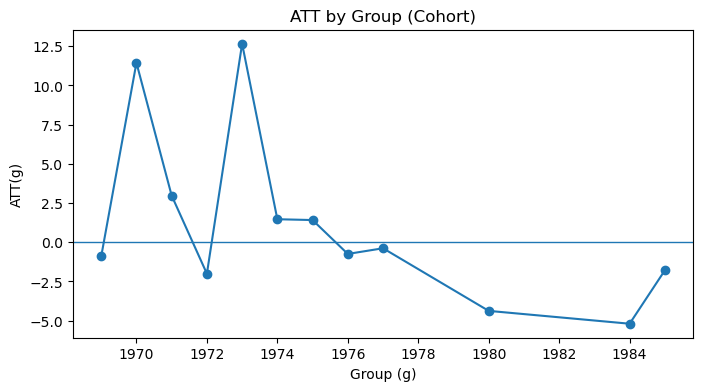

In [18]:
att_by_group = (
    att_gt
    .groupby("g")["ATT(g,t)"]
    .mean()
    .round(3)
    .reset_index()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(att_by_group["g"], att_by_group["ATT(g,t)"], marker="o")
plt.axhline(0, linewidth=1)
plt.title("ATT by Group (Cohort)")
plt.xlabel("Group (g)")
plt.ylabel("ATT(g)")
plt.savefig(r"C:\Users\User\Desktop\CSDiD\Python\Output\By_group.png",
            dpi=300, bbox_inches="tight")
plt.show()



### 2) By period

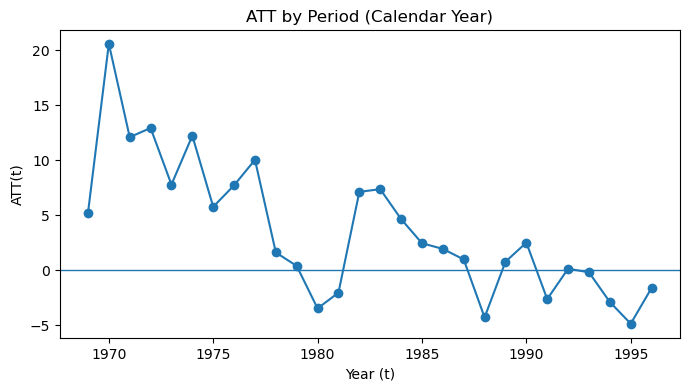

In [19]:
att_by_period = (
    att_gt
    .groupby("t")["ATT(g,t)"]
    .mean()
    .round(3)
    .reset_index()
)

plt.figure(figsize=(8,4))
plt.plot(att_by_period["t"], att_by_period["ATT(g,t)"], marker="o")
plt.axhline(0, linewidth=1)
plt.title("ATT by Period (Calendar Year)")
plt.xlabel("Year (t)")
plt.ylabel("ATT(t)")
plt.savefig(r"C:\Users\User\Desktop\CSDiD\Python\Output\By_period.png",
            dpi=300, bbox_inches="tight")
plt.show()



### 3) Event-time ATT



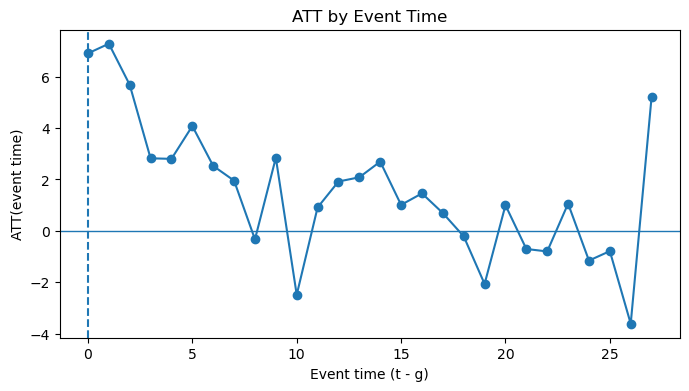

In [20]:
event_time = t - g
att_gt["event_time"] = att_gt["t"] - att_gt["g"]

att_by_event = (
    att_gt
    .groupby("event_time")["ATT(g,t)"]
    .mean()
    .round(3)
    .reset_index()
)

plt.figure(figsize=(8,4))
plt.plot(att_by_event["event_time"], att_by_event["ATT(g,t)"], marker="o")
plt.axhline(0, linewidth=1)
plt.axvline(0, linestyle="--")
plt.title("ATT by Event Time")
plt.xlabel("Event time (t - g)")
plt.ylabel("ATT(event time)")
plt.savefig(r"C:\Users\User\Desktop\CSDiD\Python\Output\By_event.png",
            dpi=300, bbox_inches="tight")
plt.show()


# c) Explanation of Aggregations


## Meaning of aggregation by group
Aggregation by group averages the ATT(g,t) **within each treatment cohort g**.  
It answers the question:

> “What is the average treatment effect for units that adopted the policy in the same year?”

This measure highlights **heterogeneity across cohorts**, showing whether early adopters experienced stronger or weaker effects than later adopters. It is cohort-focused rather than time-focused.

---

## Meaning of aggregation by period
Aggregation by period averages ATT(g,t) **across cohorts within the same calendar year t**.  
It answers:

> “What was the average treatment effect in year t across all groups already treated?”

This provides a **time-series view of the policy impact**, capturing how the overall effect evolves in calendar time, regardless of when each unit adopted.

---

## Meaning of aggregation by event-time
Aggregation by event-time collapses ATT(g,t) according to:

> event time = t − g

It answers:

> “How does the treatment effect evolve relative to the time of adoption?”

This creates a dynamic effect profile:

- pre-treatment periods (event time < 0)
- treatment year (0)
- post-treatment effects (event time > 0)

It provides a unified treatment timeline across cohorts.


## Which aggregation is most comparable to the TWFE Event-Study coefficients?


The aggregation **by event-time** is the most comparable to the TWFE event-study coefficients.

Reason:

TWFE event studies estimate a single coefficient for each **relative time to treatment**, implicitly pooling all cohorts and treating event time as:

> $β_k$ = average effect at event time k across groups



This matches exactly what the **event-time aggregation in CSDiD** does, but:

- CSDiD handles treatment timing heterogeneity correctly
- TWFE mixes comparisons across already-treated units, leading to bias

---
TWFE output reflects:

- a single pooled "post" effect
- estimates coming from comparisons that include already-treated units
- potential bias from treatment timing heterogeneity

The **CSDiD event-time aggregation** produces the *clean, unbiased counterpart* to those dynamic TWFE coefficients.

---


# d) Compare CSDiD and Event-Study Results


In [23]:
import pandas as pd

twfe_data = {
    -5:  -2.0155,
    -4:   0.6390,
    -3:  -1.9172,
    -2:  -0.2643,
     0:  -0.1031,
     1:  -1.6420,
     2:  -1.6764,
     3:  -0.7999,
     4:  -2.8406,
     5:  -2.0486,
     6:  -3.1014,
     7:  -4.8027,
     8:  -6.7096,
     9:  -4.4550,
    10:  -8.6507,
    11:  -7.1742,
    12:  -6.2905,
    13:  -8.2887,
    14:  -6.7403,
    15:  -8.3004,
    16:  -7.6370,
    17:  -8.9110,
    18: -10.7430,
    19: -12.1530,
    20:  -9.6865
}

twfe_ev = pd.DataFrame(
    {"event_time": list(twfe_data.keys()),
     "TWFE": list(twfe_data.values())}
).sort_values("event_time")



,event_time,TWFE
0,-5,-2.0155
1,-4,0.6390
2,-3,-1.9172
3,-2,-0.2643
4,0,-0.1031
5,1,-1.6420
6,2,-1.6764
7,3,-0.7999
8,4,-2.8406
9,5,-2.0486


In [24]:
comparison = pd.merge(
    att_by_event,
    twfe_ev,
    on="event_time",
    how="outer"
).sort_values("event_time")

comparison


,event_time,"ATT(g,t)",TWFE
0,-5,NaN,-2.0155
1,-4,NaN,0.6390
2,-3,NaN,-1.9172
3,-2,NaN,-0.2643
4,0,6.902,-0.1031
5,1,7.277,-1.6420
6,2,5.679,-1.6764
7,3,2.821,-0.7999
8,4,2.800,-2.8406
9,5,4.077,-2.0486


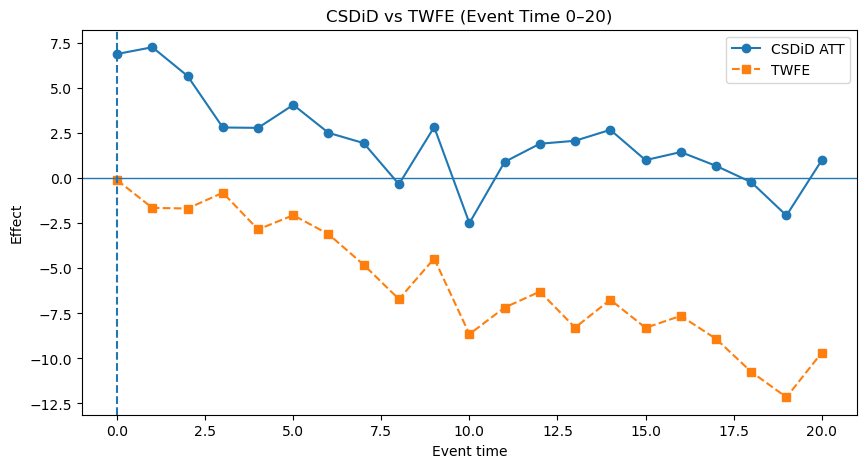

In [28]:
import matplotlib.pyplot as plt

# Filtrar rango deseado
comp_lim = comparison[
    (comparison["event_time"] >= 0) &
    (comparison["event_time"] <= 20)
]

plt.figure(figsize=(10,5))

plt.plot(
    comp_lim["event_time"],
    comp_lim["ATT(g,t)"],
    marker="o",
    label="CSDiD ATT"
)

plt.plot(
    comp_lim["event_time"],
    comp_lim["TWFE"],
    marker="s",
    linestyle="--",
    label="TWFE"
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linestyle="--")

plt.xlabel("Event time")
plt.ylabel("Effect")
plt.title("CSDiD vs TWFE (Event Time 0–20)")
plt.legend()
plt.savefig(r"C:\Users\User\Desktop\CSDiD\Python\Output\CSDid vs TWFE.png",
            dpi=300, bbox_inches="tight")
plt.show()



## Comparison between CSDiD and TWFE

The combined plot reveals clear differences in the dynamic treatment effects estimated by CSDiD and TWFE:

1. **Direction and magnitude**
   - TWFE estimates consistently show **more negative effects**, reaching values below -10 after event-time 15.
   - CSDiD estimates remain **closer to zero and positive in early periods**, suggesting smaller post-treatment impacts.

2. **Post-treatment trend**
   - TWFE exhibits a **monotonic downward trend**, implying progressively larger negative effects over time.
   - CSDiD shows a **moderate decline with fluctuations**, indicating more stable and less extreme estimated effects.

3. **Interpretation**
   - The divergence suggests that TWFE is likely affected by **treatment effect heterogeneity and negative weighting**, which can bias estimates downward when treated units serve as controls for later-treated units.
   - CSDiD corrects for this issue by using only valid comparisons, producing effects that are **less biased and more credible** under staggered adoption.

Overall, the CSDiD results suggest modest treatment effects, while TWFE exaggerates negative impacts, highlighting the importance of using methods designed for staggered treatment settings.
